## Playing around with attendance data

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

cities = pd.read_csv("../data/cities.csv")

# I'm going to assume "trip" == "event"
events = pd.read_excel("../data/MHC Trip Summary.xlsx")
# Remove nans for city and site type 
events = events.dropna(subset=["City", "Site Types"])

# Remove rows that have only nan
nan2zero_cols = "All Women (not pregnant 18+)", "Pregnant Patients (all ages)", "Children 1-18 years", "All infants <1 year"
non_all_nan_rows = ~np.all(np.isnan(events.loc[:, nan2zero_cols].values), axis=1)
events = events.loc[non_all_nan_rows,:]

# Fill the remaining gaps with zeros
events.loc[:,nan2zero_cols] = events.loc[:,nan2zero_cols].fillna(0)


events = pd.merge(events, cities.loc[:,["city","pop"]], left_on="City", right_on="city")

# Split multi-valued items
events["Site Types"] = events["Site Types"].apply(lambda st : np.array(st.split(";")) )
events["Site Types Pretty"] = events["Site Types"].apply(lambda st : ", ".join(st) )



# Total foot traffic calculation
events["Foot traffic"] = events["All Men"] + events["All Women (not pregnant 18+)"] + events["Pregnant Patients (all ages)"] + events["Children 1-18 years"] + events["All infants <1 year"]


display(events)



,Date,City,Physical location,Site Types,Latitude,Longitude,Organizer,Services offered,Total Pharmacists,Total APPE Students,...,Patients referred to other sites.1,Patients needing f/u.1,Patients who were seen at f/u.1,Patients not seen at f/u.1,New diagnosis noted at f/u.1,Interventions made at appointment.1,city,pop,Site Types Pretty,Foot traffic
0,2024-08-02 00:00:00,Ottawa,Ottawa Schools,[Special Event],41.028836,-84.046572,HealthWise,BP + BG,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ottawa,4456,Special Event,28.0
1,9/10/2024-9/13/2024,Kenton,Hardin County Fairgrounds,[Special Event],40.631205,-83.610080,NaN,"BP, BG, lipids",4,3,...,NaN,NaN,NaN,NaN,NaN,NaN,Kenton,7947,Special Event,60.0
2,2024-09-21 00:00:00,Ada,Downtown Ada,[Special Event],40.769433,-83.823181,Harvest and Herb,BP + BG + lipids,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ada,5334,Special Event,16.0
3,2024-09-21 00:00:00,Lima,Reading Park,[Special Event],40.742964,-84.120592,Mercy Block Party,BP,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Special Event,30.0
4,2024-09-24 00:00:00,Lima,AAA Lima,[Special Event],40.748349,-84.148803,AAA Falls Day,BP + BMD,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Special Event,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2025-05-02 00:00:00,Ada,ONU Day of Giving,[Special Event],40.769433,-83.823181,HW,BP,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Ada,5334,Special Event,18.0
74,2025-05-06 00:00:00,Lima,Mercy Thrift Store,[Thrift store],40.743039,-84.111477,HealthWise,MHC,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Thrift store,4.0
75,2025-05-07 00:00:00,Lima,Christian Corner,[Food Bank],40.712793,-84.107995,HealthWise,MHC,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,Food Bank,7.0
76,2025-05-08 00:00:00,Bluffton,Bluffton Library,[Library],40.892385,-83.892901,HealthWise,NaN,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Bluffton,3967,Library,3.0


## Helper functions

In [224]:
def remove_special_events(events):

    no_special_events_mask = np.logical_not(events["Site Types"].apply(lambda t : (t == "Special Event").all()))
    return events.loc[no_special_events_mask,:]



def plot_site_type(events, filter_value=None, legend=True, group_attr="Physical location", x_var="pop"):

    events = remove_special_events(events)

    if filter_value != None: 
        site_type_mask = events["Site Types"].apply(lambda t : (t == filter_value).any())
        events = events.loc[site_type_mask,:]

    site_set = set(events[group_attr])

    fig, ax = plt.subplots()

    for site in site_set:
        x = events.loc[events[group_attr] == site, x_var]
        y = events.loc[events[group_attr] == site,"Foot traffic"]

        current_city = events.loc[events[group_attr] == site,"city"].values[0]

        label = f"{site}"
        ax.scatter(x, y, label=label)

    if legend:
        plt.legend()

    if filter_value is not None:
        plt.title(f"Expected attendance at {filter_value} sites")
    else:
        plt.title(f"Expected attendance across all sites")

    fig.set_size_inches(8, 5)

    plt.show()

## Examining attenance as a function of population and site type
_Reflections_: It doesn't seem that population is a big determinant of expected attendance 

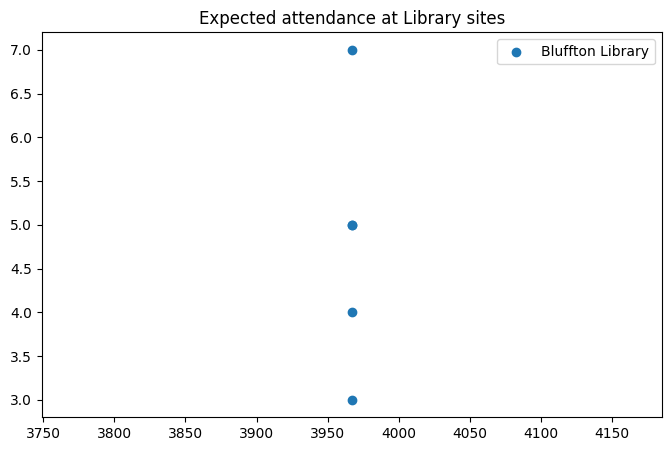

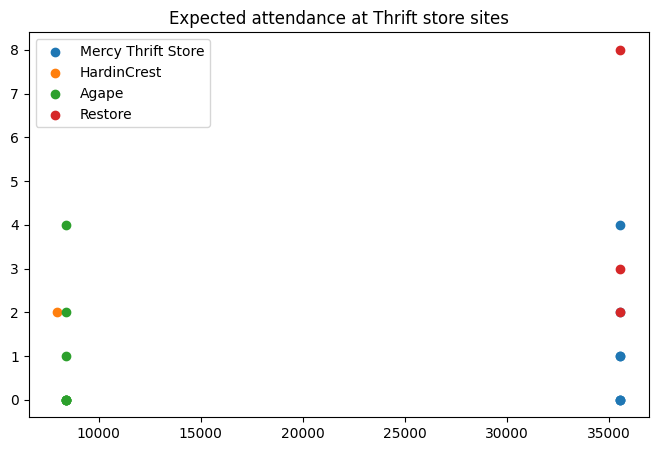

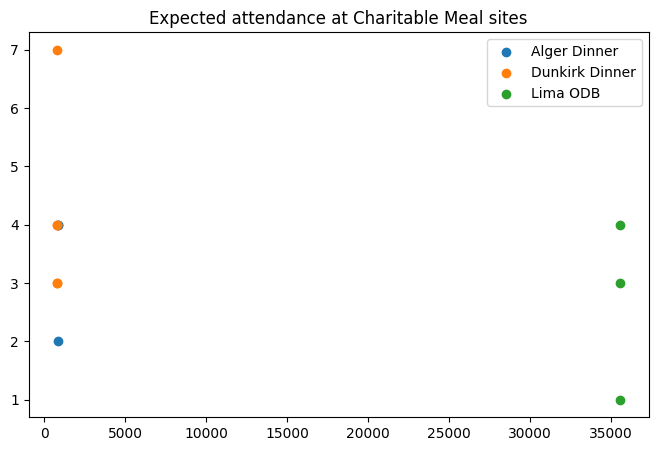

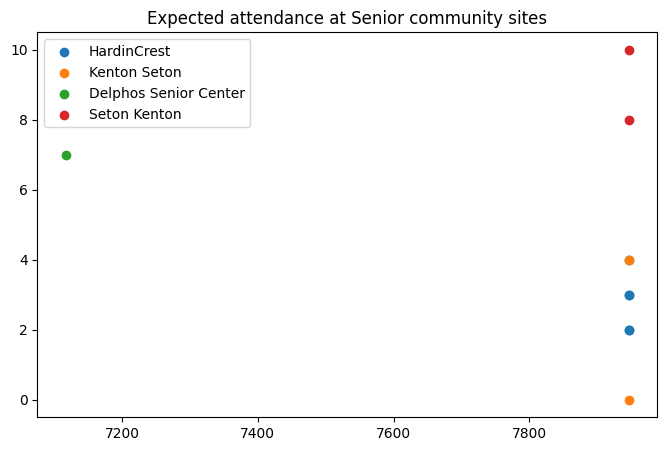

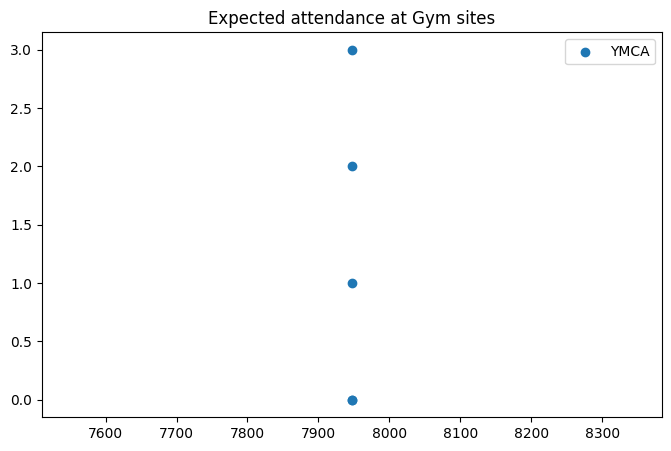

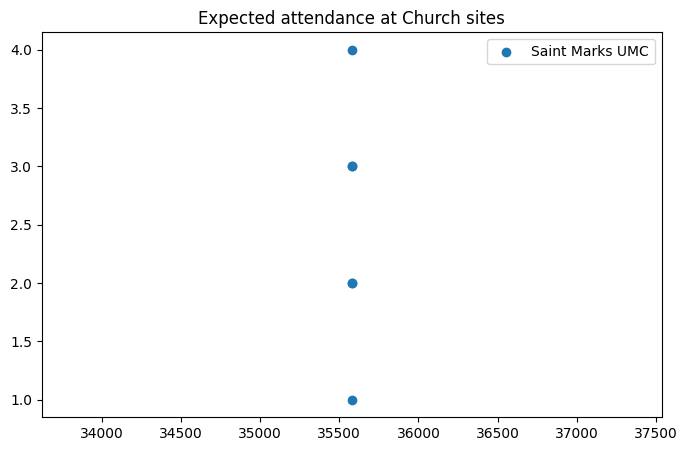

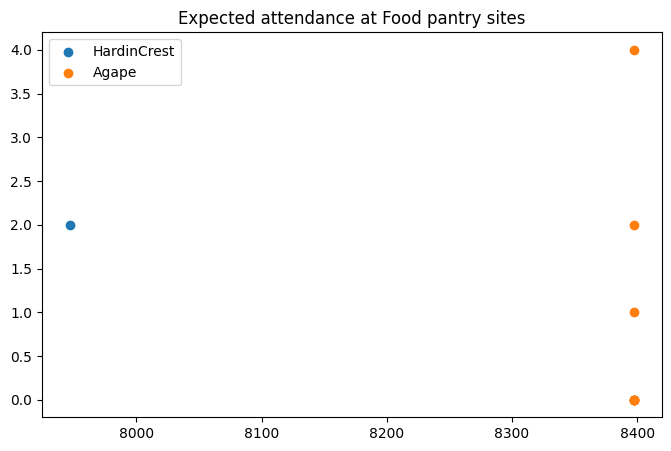

In [225]:
plot_site_type(events, filter_value="Library")
plot_site_type(events, filter_value="Thrift store")
plot_site_type(events, filter_value='Charitable Meal')
plot_site_type(events, filter_value="Senior community")
plot_site_type(events, filter_value="Gym")
plot_site_type(events, filter_value="Church")
plot_site_type(events, "Food pantry")

## Examining attendance as a function of population
_Reflections:_ It looks like population really isn't a big determinant of expected attendance 

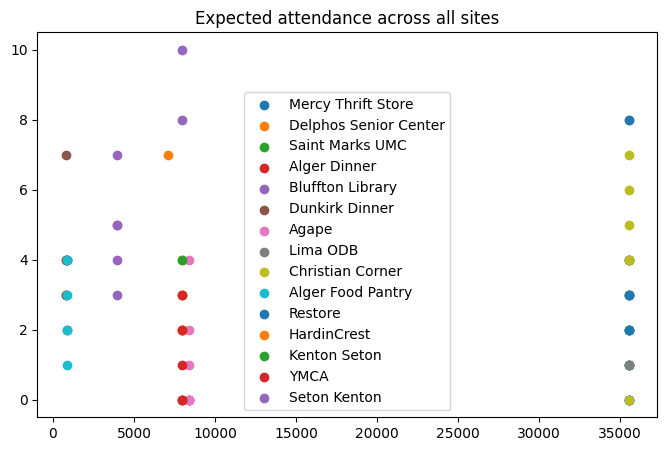

In [226]:
plot_site_type(events, legend=True, group_attr="Physical location")

## Examining event type versus attendance

<Axes: title={'center': 'Foot traffic'}, xlabel='Site Types Pretty'>

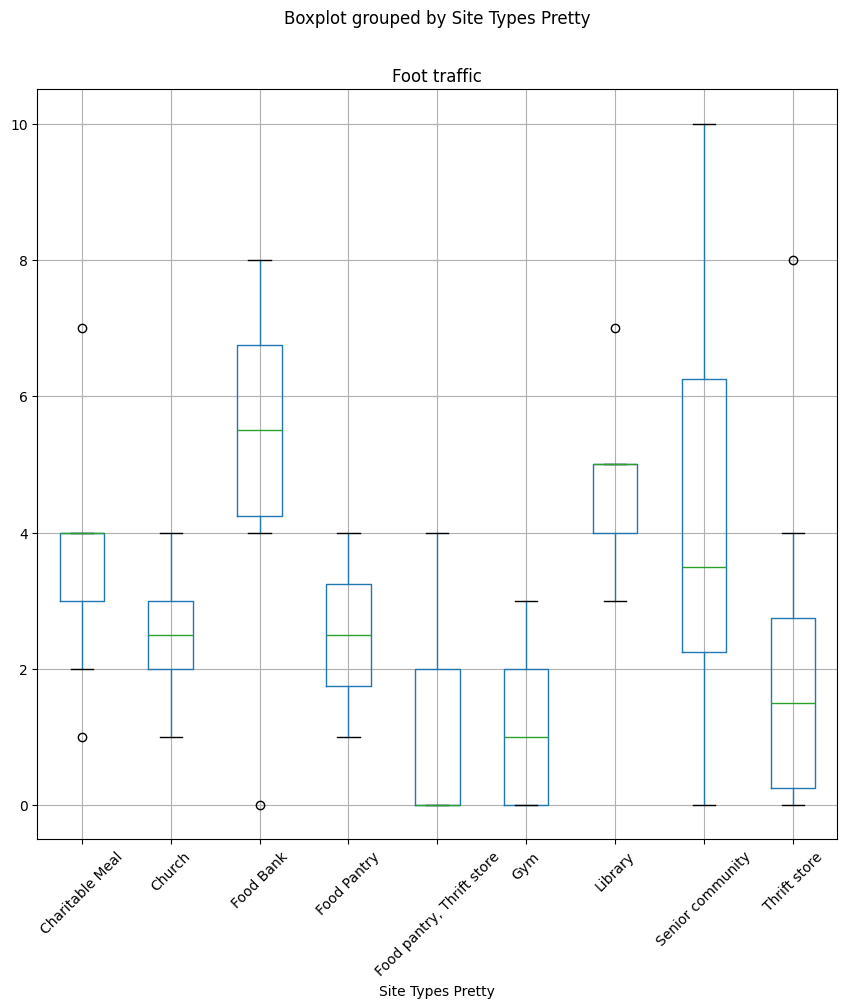

In [227]:
events_no_special = remove_special_events(events)

events_no_special.boxplot(column="Foot traffic", by="Site Types Pretty", figsize=(10,10),rot=45)

## Corellation analysis

C:\Users\i-kropp\AppData\Local\Temp\ipykernel_29392\1651751771.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numbery_events = numbery_events.replace({"city" : city_dict,


,Foot traffic,Site Types Pretty,pop,city,Physical location
Foot traffic,1.000000,0.295156,-0.043792,0.142814,0.146787
Site Types Pretty,0.295156,1.000000,0.299604,-0.123285,0.107963
pop,-0.043792,0.299604,1.000000,0.326251,-0.258623
city,0.142814,-0.123285,0.326251,1.000000,-0.323270
Physical location,0.146787,0.107963,-0.258623,-0.323270,1.000000


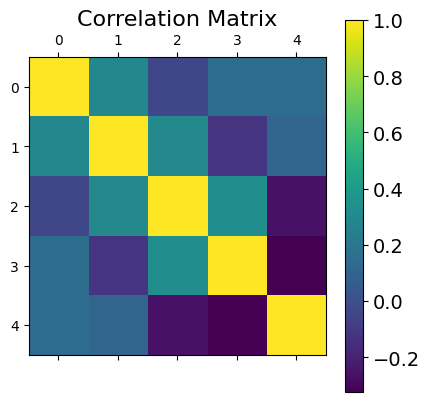

In [259]:
def dictionize_df(df, attr): 
    discrete_vals = set(df.loc[:,attr].values)
    dictionary = {value: number for (number, value) in enumerate(discrete_vals)}
    return dictionary


city_dict = dictionize_df(events, "city")
loca_dict = dictionize_df(events, "Physical location")
type_dict = dictionize_df(events, "Site Types Pretty")

attributes = ["Foot traffic", "Site Types Pretty", "pop", "city", "Physical location"]
numbery_events = events_no_special.loc[:,attributes]
numbery_events = numbery_events.replace({"city" : city_dict, 
                                         "Physical location": loca_dict,
                                         "Site Types Pretty" : type_dict})


corr_mat = numbery_events.corr()
display(corr_mat)

plt.matshow(corr_mat)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);
plt.show()

